# 02 - Python Image Handling For Inspection Workflows

**Purpose:** Demonstrate how uploaded/camera product images are handled programmatically before AI inference.

**Expected output:** Real bottle image loaded with OpenCV, converted for Matplotlib, manipulated as a NumPy array, cropped, resized, rotated, and visualized inline.

**Platform connection:** These operations mirror the image handling that happens inside the backend inspection pipeline.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Read A Real MVTec Image With OpenCV


,image,opencv_shape,dtype,min_pixel,max_pixel
0,C:\Users\HP\Desktop\springboard\visioninspect-...,"(900, 900, 3)",uint8,27,255


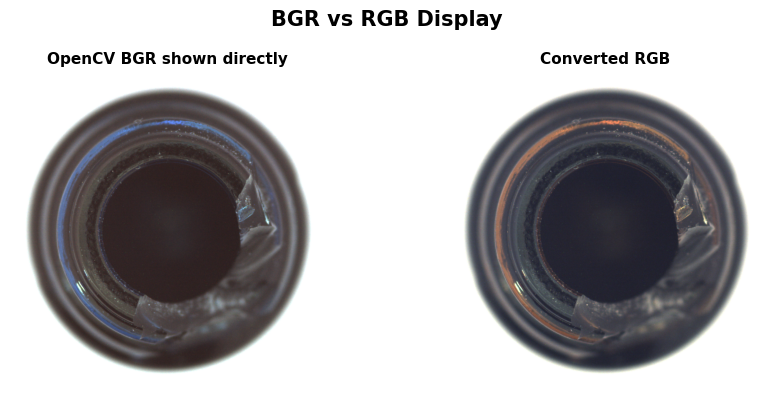

In [2]:
image_path = first_image("broken_large", "test")
image_bgr = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

display(pd.DataFrame([{
    "image": str(image_path),
    "opencv_shape": str(image_bgr.shape),
    "dtype": str(image_bgr.dtype),
    "min_pixel": int(image_bgr.min()),
    "max_pixel": int(image_bgr.max()),
}]))
show_grid([("OpenCV BGR shown directly", image_bgr, None), ("Converted RGB", image_rgb, None)], cols=2, figsize=(9, 4), suptitle="BGR vs RGB Display")


## Image As A NumPy Array


In [3]:
channel_stats = []
for idx, name in enumerate(["red", "green", "blue"]):
    channel = image_rgb[:, :, idx]
    channel_stats.append({"channel": name, "mean": round(float(channel.mean()), 2), "std": round(float(channel.std()), 2), "min": int(channel.min()), "max": int(channel.max())})
print("Array type:", type(image_rgb))
print("Shape:", image_rgb.shape)
print("Center pixel RGB:", image_rgb[image_rgb.shape[0] // 2, image_rgb.shape[1] // 2].tolist())
display(pd.DataFrame(channel_stats))


Array type: <class 'numpy.ndarray'>
Shape: (900, 900, 3)
Center pixel RGB: [46, 46, 53]


,channel,mean,std,min,max
0,red,138.41,92.72,27,255
1,green,137.63,92.68,29,255
2,blue,142.07,88.21,34,255


## Split Channels, Crop, Resize, Rotate, Flip


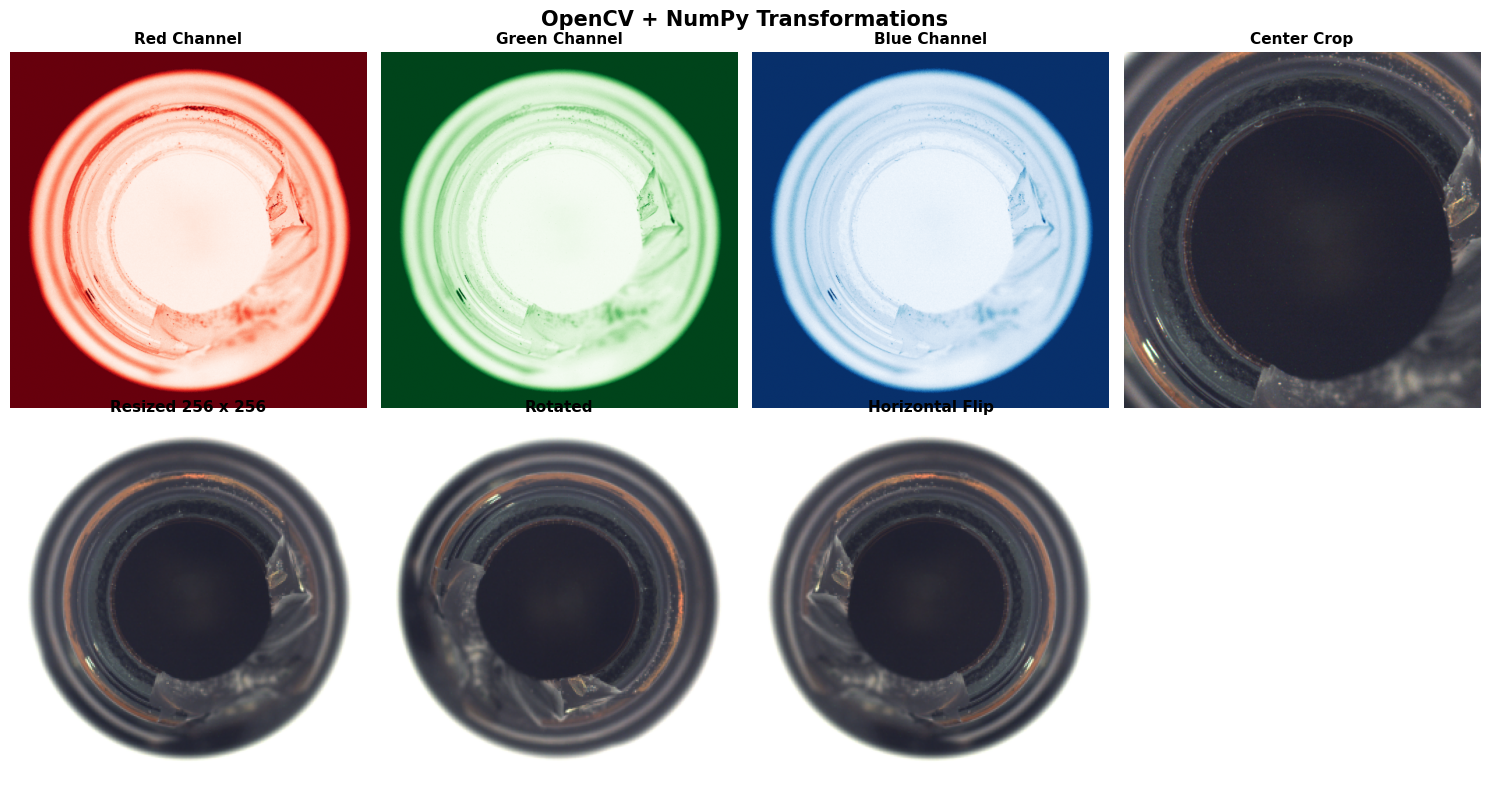

In [4]:
red, green, blue = image_rgb[:, :, 0], image_rgb[:, :, 1], image_rgb[:, :, 2]
h, w = image_rgb.shape[:2]
crop = image_rgb[int(h * 0.18):int(h * 0.78), int(w * 0.18):int(w * 0.78)]
resized = cv2.resize(image_rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
rotated = cv2.rotate(resized, cv2.ROTATE_90_CLOCKWISE)
flipped = cv2.flip(resized, 1)
show_grid([
    ("Red Channel", red, "Reds"), ("Green Channel", green, "Greens"), ("Blue Channel", blue, "Blues"),
    ("Center Crop", crop, None), ("Resized 256 x 256", resized, None), ("Rotated", rotated, None), ("Horizontal Flip", flipped, None),
], cols=4, figsize=(15, 8), suptitle="OpenCV + NumPy Transformations")


## Pixel Manipulation In Memory


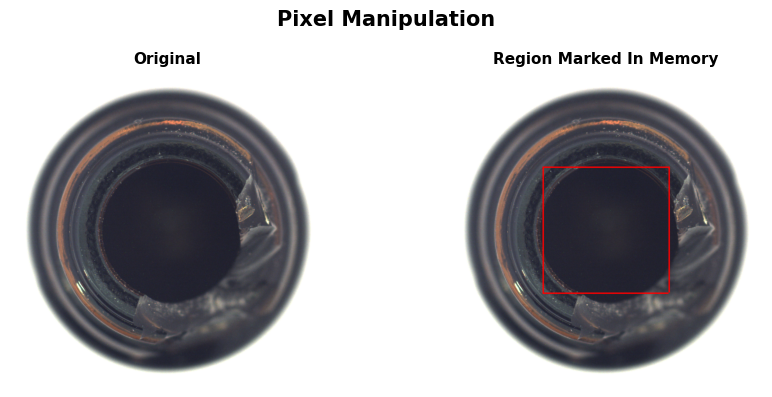

In [5]:
marked = image_rgb.copy()
y1, y2 = int(h * 0.30), int(h * 0.70)
x1, x2 = int(w * 0.30), int(w * 0.70)
marked[y1:y1+4, x1:x2] = [255, 0, 0]
marked[y2:y2+4, x1:x2] = [255, 0, 0]
marked[y1:y2, x1:x1+4] = [255, 0, 0]
marked[y1:y2, x2:x2+4] = [255, 0, 0]
show_grid([("Original", image_rgb, None), ("Region Marked In Memory", marked, None)], cols=2, figsize=(9, 4), suptitle="Pixel Manipulation")


## In-Memory Format Encoding


In [6]:
rows = []
for ext in [".png", ".jpg", ".bmp"]:
    success, buffer = cv2.imencode(ext, image_bgr)
    rows.append({"format": ext.upper().replace(".", ""), "success": bool(success), "encoded_size_kb": round(len(buffer) / 1024, 2) if success else None})
display(pd.DataFrame(rows))


,format,success,encoded_size_kb
0,PNG,True,666.50
1,JPG,True,139.21
2,BMP,True,2373.10


## Image Acquisition Validation Checks

Before AI inference, the backend should reject unreadable or structurally invalid images. This mirrors the upload validation step in the app.


,label,file,readable,height,width,channels,valid_for_pipeline
0,good,000.png,True,900,900,3,True
1,broken_large,000.png,True,900,900,3,True
2,broken_small,000.png,True,900,900,3,True
3,contamination,000.png,True,900,900,3,True


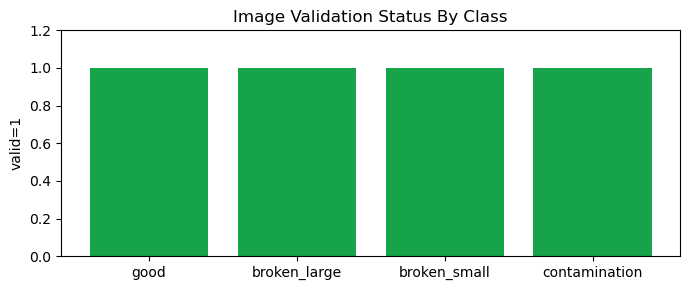

In [7]:
validation_rows = []
for label in LABELS:
    path = first_image(label, "test")
    img = cv2.imread(str(path))
    validation_rows.append({
        "label": label,
        "file": path.name,
        "readable": img is not None,
        "height": img.shape[0] if img is not None else None,
        "width": img.shape[1] if img is not None else None,
        "channels": img.shape[2] if img is not None and img.ndim == 3 else 1,
        "valid_for_pipeline": img is not None and img.ndim == 3 and img.shape[2] == 3,
    })
validation_df = pd.DataFrame(validation_rows)
display(validation_df)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(validation_df["label"], validation_df["valid_for_pipeline"].astype(int), color="#16a34a")
ax.set_ylim(0, 1.2)
ax.set_title("Image Validation Status By Class")
ax.set_ylabel("valid=1")
plt.tight_layout()
plt.show()


## Validation Outcome

- The project can read and display real product images correctly.
- RGB conversion is required for correct visualization.
- NumPy operations support crop, resize, channel analysis, rotation, and in-memory manipulation.
